# DATA ANALYTICS

## MODEL FOR ANALYSIS

# Integrating the raw data to clean  for BIOMETRICS and DEMOGRAPHICS

## Biometric code

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

file_1 =  ["/content/api_data_aadhar_biometric_0_500000.csv","/content/api_data_aadhar_biometric_1000000_1500000.csv","/content/api_data_aadhar_biometric_1500000_1861108.csv","/content/api_data_aadhar_biometric_500000_1000000.csv"]
file_2 = ["/content/api_data_aadhar_demographic_0_500000.csv","/content/api_data_aadhar_demographic_1000000_1500000.csv","/content/api_data_aadhar_demographic_1500000_2000000.csv","/content/api_data_aadhar_demographic_2000000_2071700.csv","/content/api_data_aadhar_demographic_500000_1000000.csv"]

df_1 = pd.concat([pd.read_csv(file)  for file in file_1], ignore_index=True)
df_2 = pd.concat([pd.read_csv(file)  for file in file_2], ignore_index=True)

############################ biometrics###############################3
df_1.columns = [ 'date', 'state', 'district', 'pincode', 'bio_age_5_17', 'bio_age_17_']
df_1 = df_1.drop('index', axis=1, errors='ignore')
df_1['date'] = pd.to_datetime(df_1['date'], format='mixed', dayfirst=True)    # encoding of date

# Single numeric column
df_1['date_encoded'] = df_1['date'].apply(lambda x: x.toordinal())

print("total records :",len(df_1))
print("Unique raw state:",df_1['state'].nunique())
# df_1

df_1['state_clean'] = df_1['state'].astype(str).str.strip().str.lower()
df_1['state_clean']
######################################### (--)############################

state_mapping = {
    # Common variations
    'andaman and nicobar islands': 'Andaman and Nicobar Islands',
    'andaman & nicobar islands': 'Andaman and Nicobar Islands',
    'andhra pradesh': 'Andhra Pradesh',
    'arunachal pradesh': 'Arunachal Pradesh',
    'assam': 'Assam',
    'bihar': 'Bihar',
    'chandigarh': 'Chandigarh',
    'chhattisgarh': 'Chhattisgarh',
    'chhatisgarh': 'Chhattisgarh',
    'dadra and nagar haveli and daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra & nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman & diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'delhi': 'Delhi',
    'goa': 'Goa',
    'gujarat': 'Gujarat',
    'haryana': 'Haryana',
    'himachal pradesh': 'Himachal Pradesh',
    'jammu and kashmir': 'Jammu and Kashmir',
    'jammu & kashmir': 'Jammu and Kashmir',
    'jharkhand': 'Jharkhand',
    'karnataka': 'Karnataka',
    'kerala': 'Kerala',
    'ladakh': 'Ladakh',
    'lakshadweep': 'Lakshadweep',
    'madhya pradesh': 'Madhya Pradesh',
    'maharashtra': 'Maharashtra',
    'manipur': 'Manipur',
    'meghalaya': 'Meghalaya',
    'mizoram': 'Mizoram',
    'nagaland': 'Nagaland',
    'odisha': 'Odisha',
    'orissa': 'Odisha',
    'puducherry': 'Puducherry',
    'pondicherry': 'Puducherry',
    'punjab': 'Punjab',
    'rajasthan': 'Rajasthan',
    'sikkim': 'Sikkim',
    'tamil nadu': 'Tamil Nadu',
    'tamilnadu': 'Tamil Nadu',
    'telangana': 'Telangana',
    'tripura': 'Tripura',
    'uttar pradesh': 'Uttar Pradesh',
    'uttarakhand': 'Uttarakhand',
    'uttaranchal': 'Uttarakhand',
    'west bengal': 'West Bengal',
    'westbengal': 'West Bengal',
    'west bangal': 'West Bengal',
    'west bengli': 'West Bengal',
    'west  bengal': 'West Bengal',
    # Junk
    '100000': 'Invalid',
    'dar bhanga': 'Invalid',
    'puttenahalli': 'Invalid',
    'balanagar': 'Invalid',
    'jaipur': 'Invalid',
    'madanapalle': 'Invalid',
    'nagpur': 'Invalid',
    'raja annamalai puram': 'Invalid',
    'nan': 'Invalid',
    '': 'Invalid'
}

total records : 1861108
Unique raw state: 57


In [ ]:
df_1['state_final'] = df_1['state_clean'].map(state_mapping).fillna('Invalid')
# === FINAL RESULTS ===
print("\n=== CLEANING COMPLETE ===")
print("Unique states after cleaning:", df_1['state_final'].nunique())
print("Invalid records:", (df_1['state_final'] == 'Invalid').sum())

print("\nValue counts per state (sorted alphabetically):")
print(df_1['state_final'].value_counts().sort_index())

print("\nList of valid standardized states:")
valid_states = sorted([s for s in df_1['state_final'].unique() if s != 'Invalid'])
print(valid_states)
# Optional: Save the fully cleaned dataset
df_1.to_csv('cleaned_full_aadhar_biometric.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_full_aadhar_demographic.csv'")

# If you want only valid states
df_valid = df_1[df_1['state_final'] != 'Invalid'].copy()
print("\nRecords with valid states:", len(df_valid))


=== CLEANING COMPLETE ===
Unique states after cleaning: 36
Invalid records: 0

Value counts per state (sorted alphabetically):
state_final
Andaman and Nicobar Islands                   1847
Andhra Pradesh                              172065
Arunachal Pradesh                             4244
Assam                                        47643
Bihar                                        83398
Chandigarh                                    1656
Chhattisgarh                                 31997
Dadra and Nagar Haveli and Daman and Diu      1325
Delhi                                         9259
Goa                                           5428
Gujarat                                      89531
Haryana                                      26429
Himachal Pradesh                             30385
Jammu and Kashmir                            19960
Jharkhand                                    36625
Karnataka                                   141227
Kerala                                      

In [ ]:
df_1["total_enrollment_biometric"] = (
    df_1[ 'bio_age_5_17'] + df_1[ 'bio_age_17_']
)

state_summary = (
    df_1.groupby("state_final")["total_enrollment_biometric"]
    .sum()
    .reset_index()
    .sort_values(by="total_enrollment_biometric", ascending=False)
)

In [ ]:
state_summary = state_summary.reset_index(drop=True)
state_summary["overall_rank_bio"] = range(1,len(state_summary)+1)

# top 10 rank in order
top10 = state_summary.head(10).copy()
top10 = top10.reset_index(drop=True)
top10["overall_rank_bio"] = range(1,len(top10)+1)

print("The top 10 enrollment states :")
print(
    top10[["overall_rank_bio","state_final","total_enrollment_biometric"]]
    .to_string(index=False)
)

The top 10 enrollment states :
 overall_rank_bio    state_final  total_enrollment_biometric
                1  Uttar Pradesh                     9577735
                2    Maharashtra                     9226139
                3 Madhya Pradesh                     5923771
                4          Bihar                     4897587
                5     Tamil Nadu                     4698118
                6      Rajasthan                     3994955
                7 Andhra Pradesh                     3714633
                8        Gujarat                     3196514
                9   Chhattisgarh                     2648734
               10      Karnataka                     2635954


In [ ]:
df_model = df_1[df_1['state_final'] != 'Invalid'].copy()  # or use full df if you want

# 1. Label Encoding for modeling
le = LabelEncoder()
df_model['state_encoded'] = le.fit_transform(df_model['state_final'])

# 2. Save the encoder for future use (e.g., decoding predictions)
# joblib.dump(le, 'state_label_encoder.pkl')

# 3. Get the mapping dictionaries (useful for interpretation)
encode_map = dict(zip(le.classes_, le.transform(le.classes_)))          # name -> code
decode_map = dict(zip(le.transform(le.classes_), le.classes_))          # code -> name

print("Sample encoded data:")
print(df_model[['state_final', 'state_encoded']].head(10))

print("\nEncoding map (state name → number):")
print(encode_map)

print("\nDecoding map (number → state name):")
print(decode_map)

Sample encoded data:
         state_final  state_encoded
0            Haryana             11
1              Bihar              4
2  Jammu and Kashmir             13
3              Bihar              4
4         Tamil Nadu             30
5        Maharashtra             20
6            Gujarat             10
7            Gujarat             10
8             Odisha             25
9            Gujarat             10

Encoding map (state name → number):
{'Andaman and Nicobar Islands': np.int64(0), 'Andhra Pradesh': np.int64(1), 'Arunachal Pradesh': np.int64(2), 'Assam': np.int64(3), 'Bihar': np.int64(4), 'Chandigarh': np.int64(5), 'Chhattisgarh': np.int64(6), 'Dadra and Nagar Haveli and Daman and Diu': np.int64(7), 'Delhi': np.int64(8), 'Goa': np.int64(9), 'Gujarat': np.int64(10), 'Haryana': np.int64(11), 'Himachal Pradesh': np.int64(12), 'Jammu and Kashmir': np.int64(13), 'Jharkhand': np.int64(14), 'Karnataka': np.int64(15), 'Kerala': np.int64(16), 'Ladakh': np.int64(17), 'Lakshadweep': n

In [ ]:
features = ['state_encoded', 'date_encoded', 'pincode',  'bio_age_5_17','total_enrollment_biometric']  # etc.
X = df_model[features]
X

,state_encoded,date_encoded,pincode,bio_age_5_17,total_enrollment_biometric
0,11,739311,123029,280,857
1,4,739311,852121,144,513
2,13,739311,185101,643,1734
3,4,739311,802158,256,1236
4,30,739311,625514,271,1086
...,...,...,...,...,...
1861103,16,739562,682020,1,7
1861104,16,739562,682022,1,1
1861105,16,739562,682023,0,1
1861106,16,739562,682025,3,9


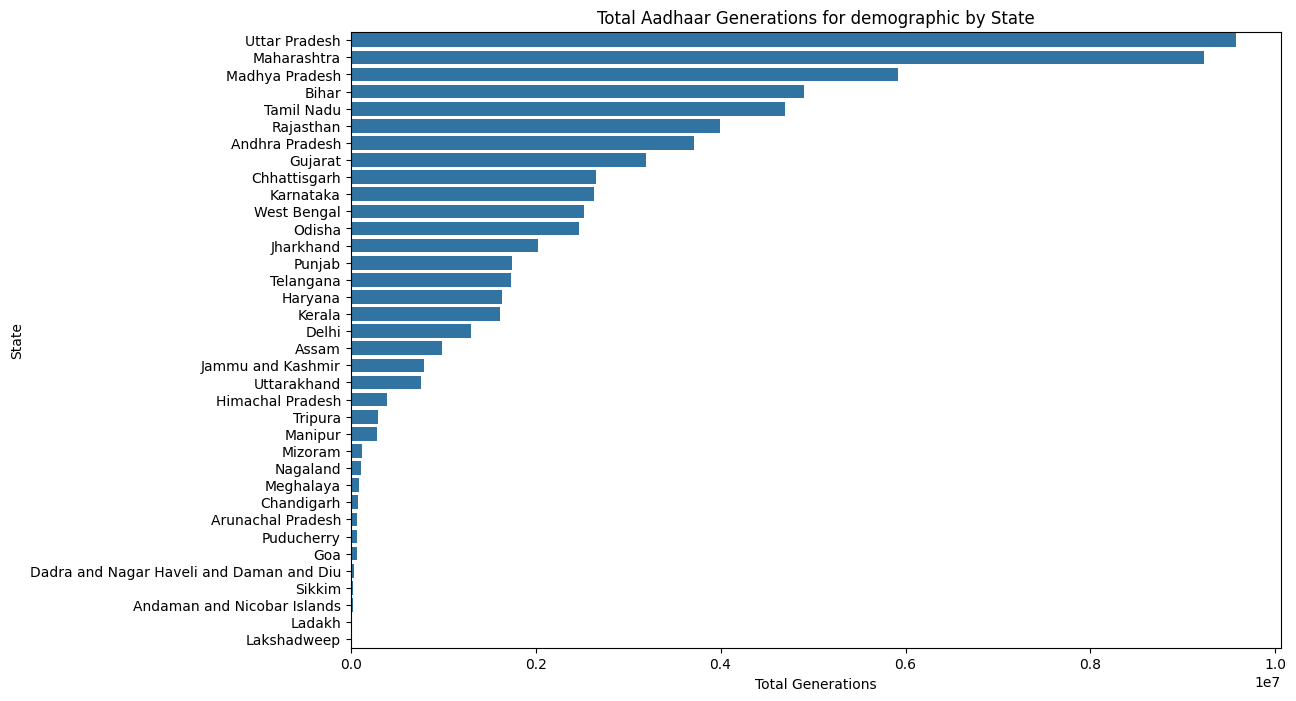

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total Aadhaar generations per state
df_model['total_aadhaar'] = df_model['bio_age_5_17'] + df_model['bio_age_17_']

state_totals = df_model.groupby('state_final')['total_aadhaar'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=state_totals.values, y=state_totals.index)
plt.title('Total Aadhaar Generations for demographic by State')
plt.xlabel('Total Generations')
plt.ylabel('State')
plt.show()

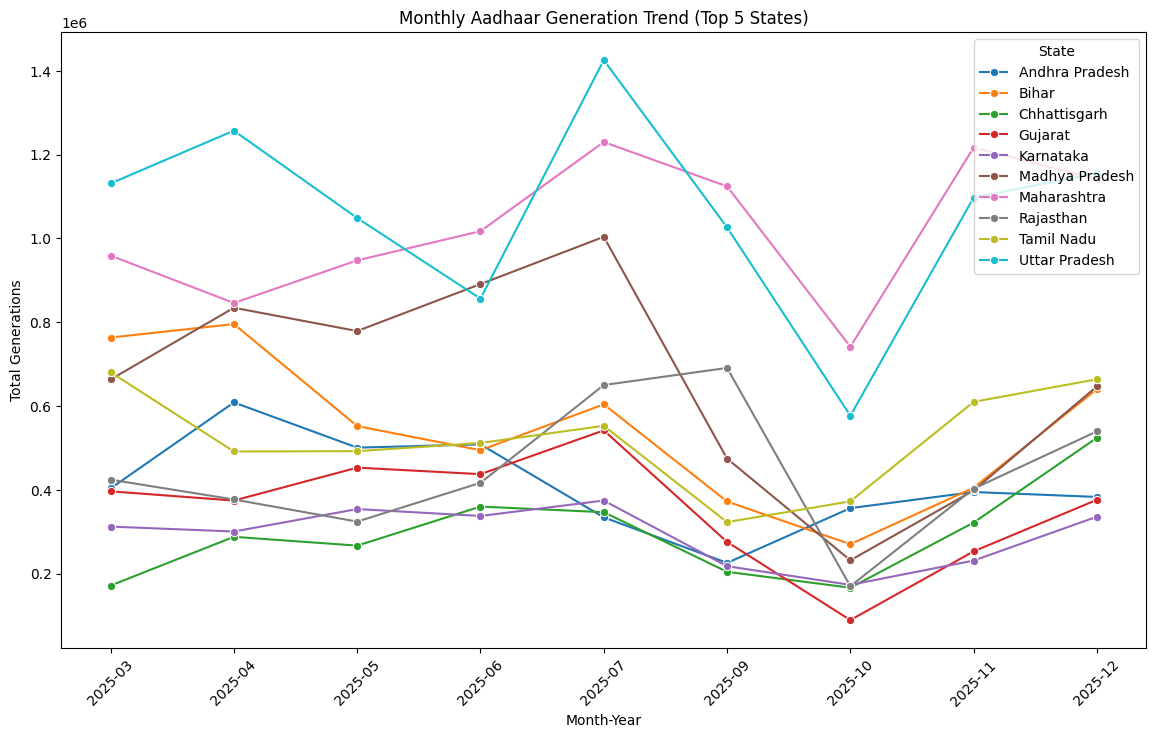

In [ ]:
# Time trend: Monthly total generations per state
df_model['month_year'] = df_model['date'].dt.to_period('M')

monthly_trend = df_model.groupby(['state_final', 'month_year'])['total_aadhaar'].sum().reset_index()
monthly_trend['month_year'] = monthly_trend['month_year'].astype(str)

# Plot for top 5 states
top_states = state_totals.head(10).index
trend_top = monthly_trend[monthly_trend['state_final'].isin(top_states)]

plt.figure(figsize=(14, 8))
sns.lineplot(data=trend_top, x='month_year', y='total_aadhaar', hue='state_final', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Aadhaar Generation Trend (Top 5 States)')
plt.xlabel('Month-Year')
plt.ylabel('Total Generations')
plt.legend(title='State')
plt.show()

In [ ]:
#####################################################

# Demographic code


In [ ]:
#####################################################

In [ ]:
######################################### (demographic)############################
df_2.columns = [ 'date', 'state', 'district', 'pincode', 'demo_age_5_17', 'demo_age_17_']
df_2 = df_2.drop('index', axis=1, errors='ignore')
df_2['date'] = pd.to_datetime(df_2['date'], format='mixed', dayfirst=True, errors='coerce')    # encoding of date

# Single numeric column
df_2['date_encoded'] = df_2['date'].apply(lambda x: x.toordinal() if pd.notna(x) else None)

print("total records :",len(df_2))
print("Unique raw state:",df_2['state'].nunique())
# df_2

df_2['state_clean'] = df_2['state'].astype(str).str.strip().str.lower()
df_2['state_clean']
##################################################################################



state_mapping = {
    # Common variations
    'andaman and nicobar islands': 'Andaman and Nicobar Islands',
    'andaman & nicobar islands': 'Andaman and Nicobar Islands',
    'andhra pradesh': 'Andhra Pradesh',
    'arunachal pradesh': 'Arunachal Pradesh',
    'assam': 'Assam',
    'bihar': 'Bihar',
    'chandigarh': 'Chandigarh',
    'chhattisgarh': 'Chhattisgarh',
    'chhatisgarh': 'Chhattisgarh',
    'dadra and nagar haveli and daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra and nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'dadra & nagar haveli': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman and diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'daman & diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'delhi': 'Delhi',
    'goa': 'Goa',
    'gujarat': 'Gujarat',
    'haryana': 'Haryana',
    'himachal pradesh': 'Himachal Pradesh',
    'jammu and kashmir': 'Jammu and Kashmir',
    'jammu & kashmir': 'Jammu and Kashmir',
    'jharkhand': 'Jharkhand',
    'karnataka': 'Karnataka',
    'kerala': 'Kerala',
    'ladakh': 'Ladakh',
    'lakshadweep': 'Lakshadweep',
    'madhya pradesh': 'Madhya Pradesh',
    'maharashtra': 'Maharashtra',
    'manipur': 'Manipur',
    'meghalaya': 'Meghalaya',
    'mizoram': 'Mizoram',
    'nagaland': 'Nagaland',
    'odisha': 'Odisha',
    'orissa': 'Odisha',
    'puducherry': 'Puducherry',
    'pondicherry': 'Puducherry',
    'punjab': 'Punjab',
    'rajasthan': 'Rajasthan',
    'sikkim': 'Sikkim',
    'tamil nadu': 'Tamil Nadu',
    'tamilnadu': 'Tamil Nadu',
    'telangana': 'Telangana',
    'tripura': 'Tripura',
    'uttar pradesh': 'Uttar Pradesh',
    'uttarakhand': 'Uttarakhand',
    'uttaranchal': 'Uttarakhand',
    'west bengal': 'West Bengal',
    'westbengal': 'West Bengal',
    'west bangal': 'West Bengal',
    'west bengli': 'West Bengal',
    'west  bengal': 'West Bengal',
    # Junk
    '100000': 'Invalid',
    'dar bhanga': 'Invalid',
    'puttenahalli': 'Invalid',
    'balanagar': 'Invalid',
    'jaipur': 'Invalid',
    'madanapalle': 'Invalid',
    'nagpur': 'Invalid',
    'raja annamalai puram': 'Invalid',
    'nan': 'Invalid',
    '': 'Invalid'
}

total records : 358190
Unique raw state: 60


In [ ]:
df_2['state_final_demo'] = df_2['state_clean'].map(state_mapping).fillna('Invalid')

# === FINAL RESULTS ===
print("\n=== CLEANING COMPLETE ===")
print("Unique states after cleaning:", df_2['state_final_demo'].nunique())
print("Invalid records:", (df_2['state_final_demo'] == 'Invalid').sum())

print("\nValue counts per state (sorted alphabetically):")
print(df_2['state_final_demo'].value_counts().sort_index())

print("\nList of valid standardized states:")
valid_states = sorted([s for s in df_2['state_final_demo'].unique() if s != 'Invalid'])
print(valid_states)

# Optional: Save the fully cleaned dataset
df_2.to_csv('cleaned_full_aadhar_demographic.csv', index=False)
print("\nCleaned dataset saved as 'cleaned_full_aadhar_demographic.csv'")

# If you want only valid states
df_valid = df_2[df_2['state_final_demo'] != 'Invalid'].copy()
print("\nRecords with valid states:", len(df_valid))


=== CLEANING COMPLETE ===
Unique states after cleaning: 37
Invalid records: 5

Value counts per state (sorted alphabetically):
state_final_demo
Andaman and Nicobar Islands                   320
Andhra Pradesh                              38720
Arunachal Pradesh                             875
Assam                                       11559
Bihar                                       17243
Chandigarh                                    352
Chhattisgarh                                 6329
Dadra and Nagar Haveli and Daman and Diu      315
Delhi                                        1925
Goa                                          1116
Gujarat                                     17197
Haryana                                      4904
Himachal Pradesh                             4670
Invalid                                         5
Jammu and Kashmir                            3546
Jharkhand                                    6885
Karnataka                                   26355
Keral

In [ ]:
df_2["total_enrollment_demographic"] = (
    df_2["demo_age_5_17"] + df_2["demo_age_17_"]
)

state_summary = (
    df_2.groupby("state_final_demo")["total_enrollment_demographic"]
    .sum()
    .reset_index()
    .sort_values(by="total_enrollment_demographic", ascending=False)
)

In [ ]:
state_summary = state_summary.reset_index(drop=True)
state_summary["overall_rank"] = range(1,len(state_summary)+1)

# top 10 rank in order
top10 = state_summary.head(10).copy()
top10 = top10.reset_index(drop=True)
top10["overall_rank"] = range(1,len(top10)+1)

print("The top 10 enrollment states :")
print(
    top10[["overall_rank","state_final_demo","total_enrollment_demographic"]]
    .to_string(index=False)
)

The top 10 enrollment states :
 overall_rank state_final_demo  total_enrollment_demographic
            1    Uttar Pradesh                     1482906.0
            2            Bihar                      886576.0
            3      Maharashtra                      868441.0
            4      West Bengal                      743548.0
            5   Madhya Pradesh                      497581.0
            6        Rajasthan                      476886.0
            7   Andhra Pradesh                      418606.0
            8       Tamil Nadu                      383235.0
            9     Chhattisgarh                      370082.0
           10          Gujarat                      369654.0


In [ ]:
df_demo_model = df_2[df_2['state_final_demo'] != 'Invalid'].copy()  # or use full df if you want

# 1. Label Encoding for modeling
le = LabelEncoder()
df_demo_model['state_encoded'] = le.fit_transform(df_demo_model['state_final_demo'])

# 2. Save the encoder for future use (e.g., decoding predictions)
# joblib.dump(le, 'state_label_encoder.pkl')

# 3. Get the mapping dictionaries (useful for interpretation)
encode_map = dict(zip(le.classes_, le.transform(le.classes_)))          # name -> code
decode_map = dict(zip(le.transform(le.classes_), le.classes_))          # code -> name

print("Sample encoded data:")
print(df_demo_model[['state_final_demo', 'state_encoded']].head(10))

print("\nEncoding map (state name → number):")
print(encode_map)

print("\nDecoding map (number → state name):")
print(decode_map)

Sample encoded data:
  state_final_demo  state_encoded
0    Uttar Pradesh             33
1   Andhra Pradesh              1
2          Gujarat             10
3   Andhra Pradesh              1
4        Rajasthan             28
5        Rajasthan             28
6        Karnataka             15
7    Uttar Pradesh             33
8   Andhra Pradesh              1
9      West Bengal             35

Encoding map (state name → number):
{'Andaman and Nicobar Islands': np.int64(0), 'Andhra Pradesh': np.int64(1), 'Arunachal Pradesh': np.int64(2), 'Assam': np.int64(3), 'Bihar': np.int64(4), 'Chandigarh': np.int64(5), 'Chhattisgarh': np.int64(6), 'Dadra and Nagar Haveli and Daman and Diu': np.int64(7), 'Delhi': np.int64(8), 'Goa': np.int64(9), 'Gujarat': np.int64(10), 'Haryana': np.int64(11), 'Himachal Pradesh': np.int64(12), 'Jammu and Kashmir': np.int64(13), 'Jharkhand': np.int64(14), 'Karnataka': np.int64(15), 'Kerala': np.int64(16), 'Ladakh': np.int64(17), 'Lakshadweep': np.int64(18), 'Madhya P

In [ ]:
features = ['state_encoded', 'date_encoded', 'pincode', 'demo_age_5_17','total_enrollment_demographic']  # etc.
X = df_demo_model[features]
X

,state_encoded,date_encoded,pincode,demo_age_5_17,total_enrollment_demographic
0,33,739311.0,273213.0,49.0,578.0
1,1,739311.0,517132.0,22.0,397.0
2,10,739311.0,360006.0,65.0,830.0
3,1,739311.0,532484.0,24.0,338.0
4,28,739311.0,313801.0,45.0,830.0
...,...,...,...,...,...
358184,30,739553.0,630312.0,0.0,1.0
358185,30,739553.0,630411.0,0.0,3.0
358186,30,739553.0,630501.0,0.0,1.0
358187,30,739553.0,630502.0,0.0,2.0


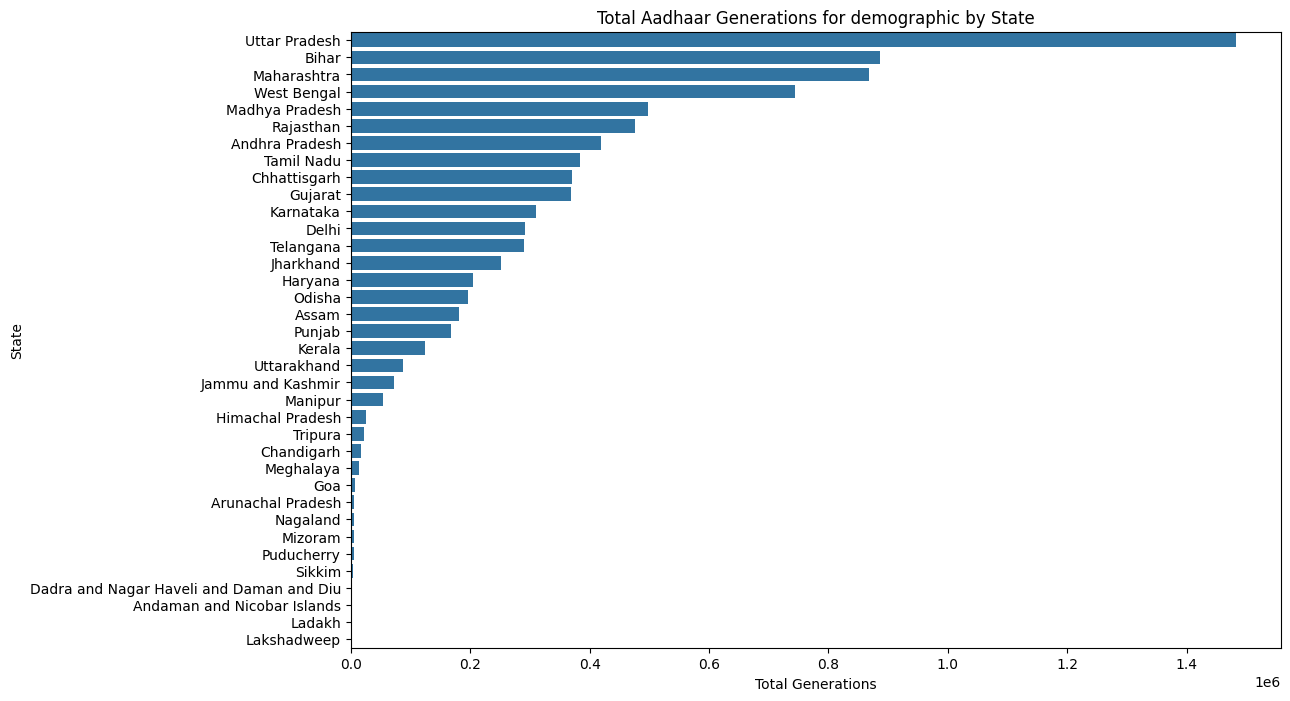

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total Aadhaar generations per state
df_demo_model['total_aadhaar'] = df_demo_model['demo_age_5_17'] + df_demo_model['demo_age_17_']

state_totals = df_demo_model.groupby('state_final_demo')['total_aadhaar'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=state_totals.values, y=state_totals.index)
plt.title('Total Aadhaar Generations for demographic by State')
plt.xlabel('Total Generations')
plt.ylabel('State')
plt.show()

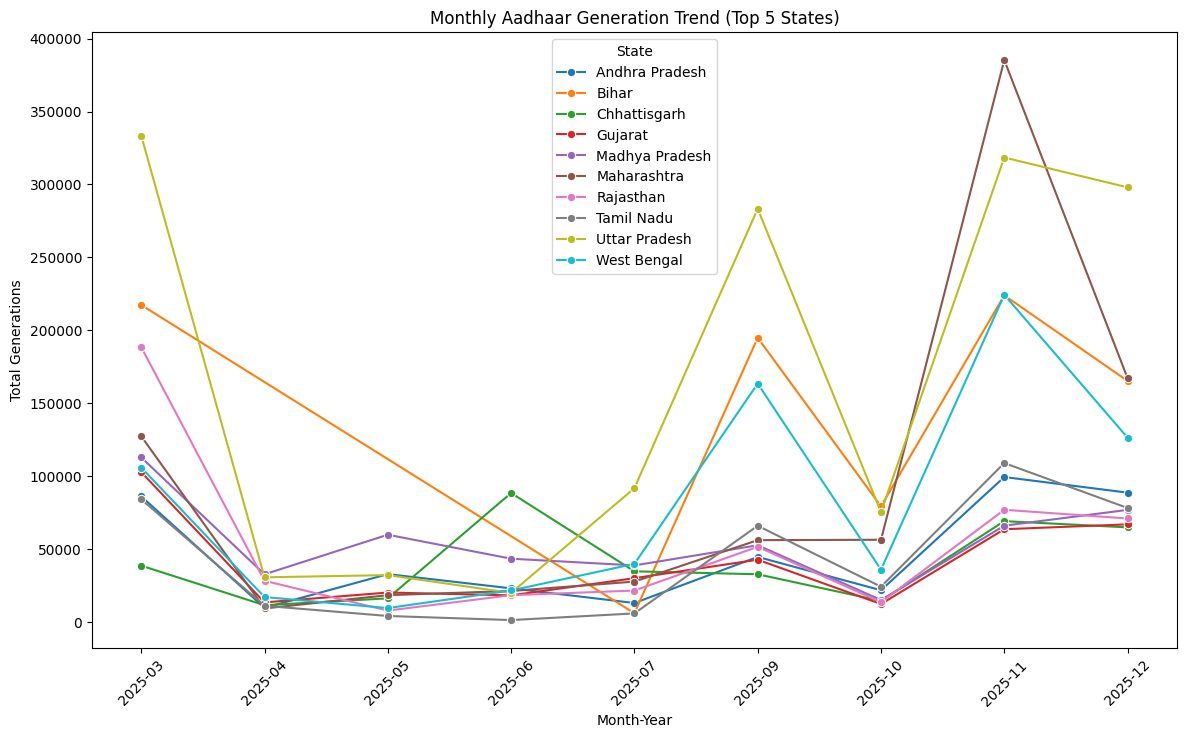

In [ ]:
# Time trend: Monthly total generations per state
df_demo_model['month_year'] = df_demo_model['date'].dt.to_period('M')

monthly_trend = df_demo_model.groupby(['state_final_demo', 'month_year'])['total_aadhaar'].sum().reset_index()
monthly_trend['month_year'] = monthly_trend['month_year'].astype(str)

# Plot for top 5 states
top_states = state_totals.head(10).index
trend_top = monthly_trend[monthly_trend['state_final_demo'].isin(top_states)]

plt.figure(figsize=(14, 8))
sns.lineplot(data=trend_top, x='month_year', y='total_aadhaar', hue='state_final_demo', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Aadhaar Generation Trend (Top 5 States)')
plt.xlabel('Month-Year')
plt.ylabel('Total Generations')
plt.legend(title='State')
plt.show()

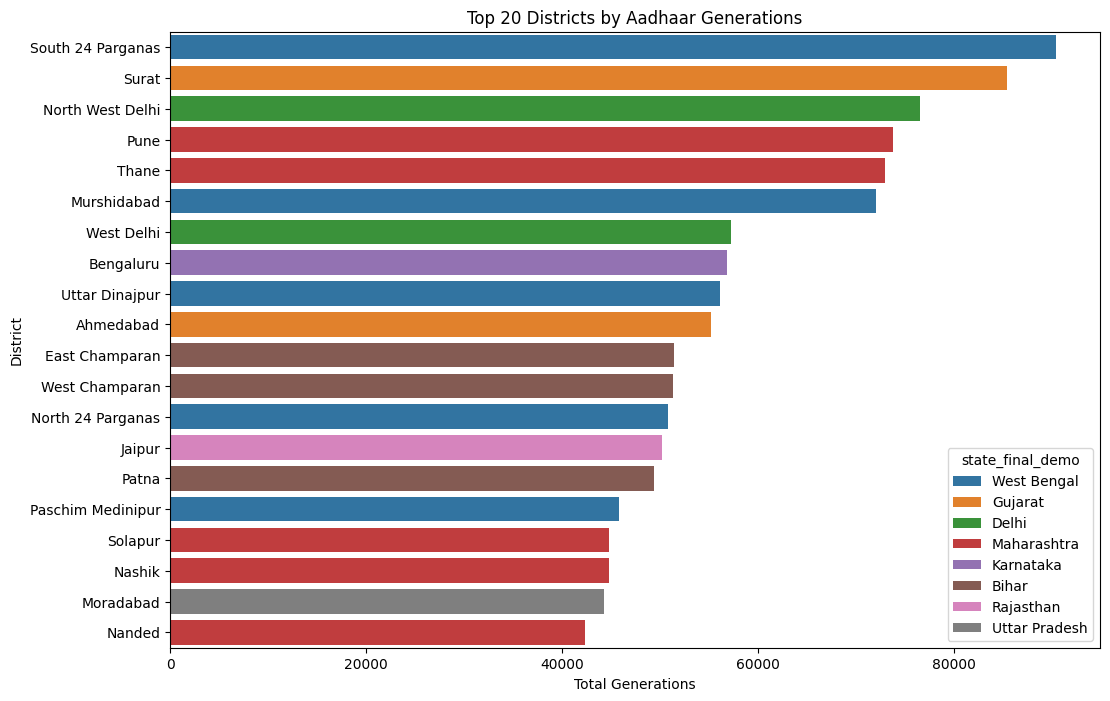

In [ ]:
# Top districts overall
top_districts = df_demo_model.groupby(['state_final_demo', 'district'])['total_aadhaar'].sum().reset_index()
top_districts = top_districts.sort_values('total_aadhaar', ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_districts, x='total_aadhaar', y='district', hue='state_final_demo')
plt.title('Top 20 Districts by Aadhaar Generations')
plt.xlabel('Total Generations')
plt.ylabel('District')
plt.show()

# combinig of biometric and demographic


In [ ]:
df_combined = pd.merge(
    df_1[[ 'date_encoded', 'state_final', 'district', 'pincode',
          'bio_age_5_17', 'bio_age_17_', 'total_enrollment_biometric']],
    df_2[['date_encoded', 'state_final_demo', 'district', 'pincode',
          'demo_age_5_17', 'demo_age_17_', 'total_enrollment_demographic']],
    left_on=['date_encoded', 'state_final', 'district', 'pincode'],
    right_on=['date_encoded', 'state_final_demo', 'district', 'pincode'],
    how='outer'
)

In [ ]:
import datetime

# By state and date (monthly or yearly)
# Add a 'date' column to df_combined for Grouper
df_combined['date'] = df_combined['date_encoded'].apply(lambda x: pd.Timestamp(datetime.date.fromordinal(int(x))) if pd.notna(x) else pd.NaT)

df_state_date = df_combined.groupby(['state_final', pd.Grouper(key='date', freq='ME')]).agg({
    'total_enrollment_biometric': 'sum',
    'total_enrollment_demographic': 'sum'
}).reset_index()

# Or overall by state
df_state_summary = df_combined.groupby('state_final').agg({
    'total_enrollment_biometric': 'sum',
    'total_enrollment_demographic': 'sum'
}).reset_index()
df_state_summary['bio_demo_ratio'] = df_state_summary['total_enrollment_biometric'] / df_state_summary['total_enrollment_demographic']

# Univariate Visualizations

/tmp/ipython-input-1648952039.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, y='state_final', x='total_enrollment_biometric', palette='viridis')


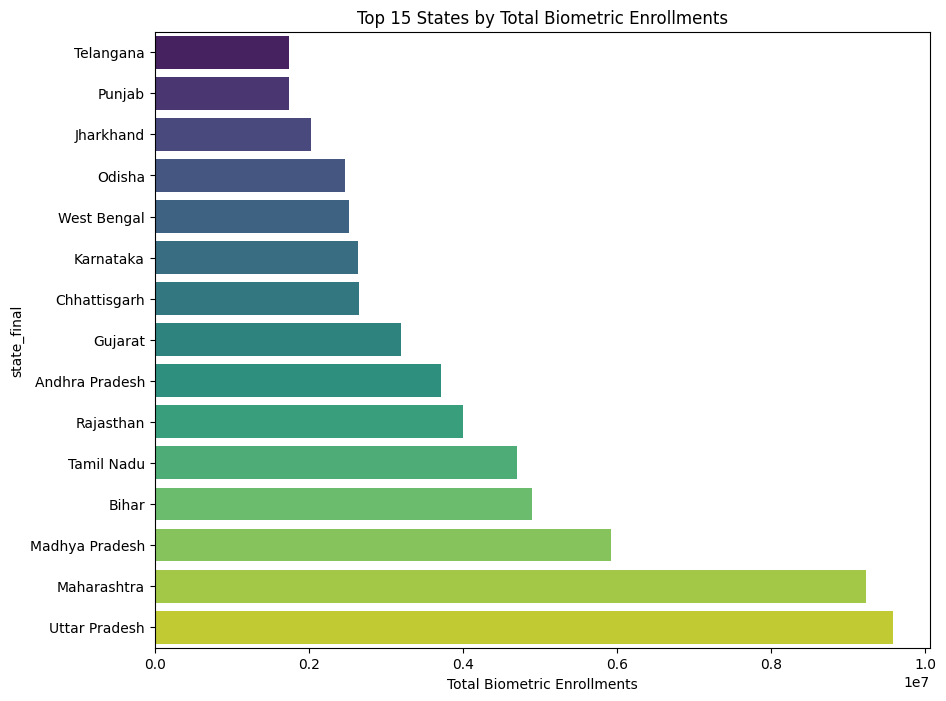

In [ ]:
top15 = df_state_summary.sort_values('total_enrollment_biometric', ascending=True).tail(15)

plt.figure(figsize=(10, 8))
sns.barplot(data=top15, y='state_final', x='total_enrollment_biometric', palette='viridis')
plt.title('Top 15 States by Total Biometric Enrollments')
plt.xlabel('Total Biometric Enrollments')
plt.show()

# Bivariate Visualizations

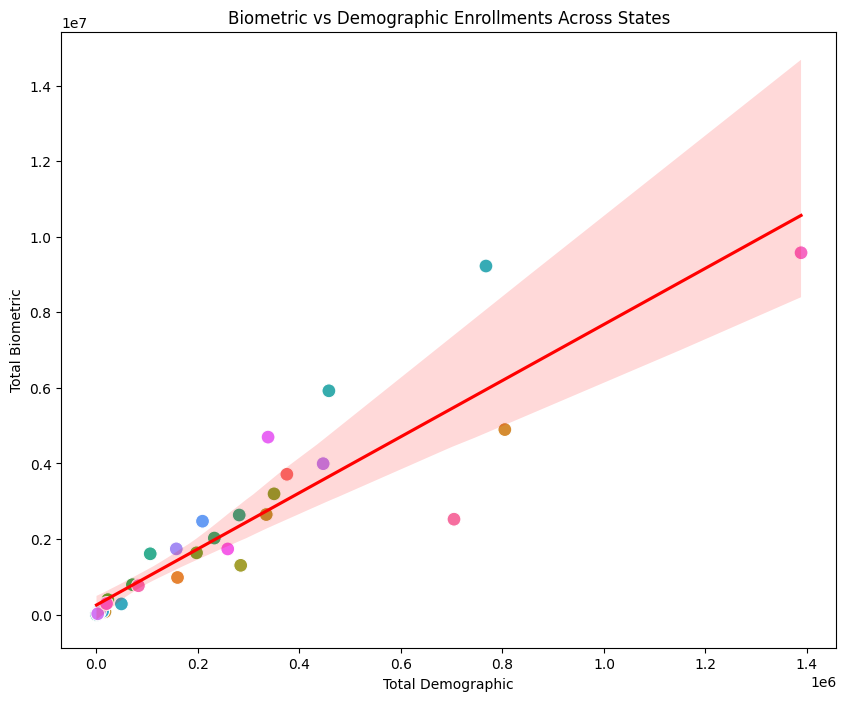

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_state_summary, x='total_enrollment_demographic',
                y='total_enrollment_biometric', hue='state_final', s=100, legend=False)
sns.regplot(data=df_state_summary, x='total_enrollment_demographic',
            y='total_enrollment_biometric', scatter=False, color='red')
plt.title('Biometric vs Demographic Enrollments Across States')
plt.xlabel('Total Demographic')
plt.ylabel('Total Biometric')
plt.show()

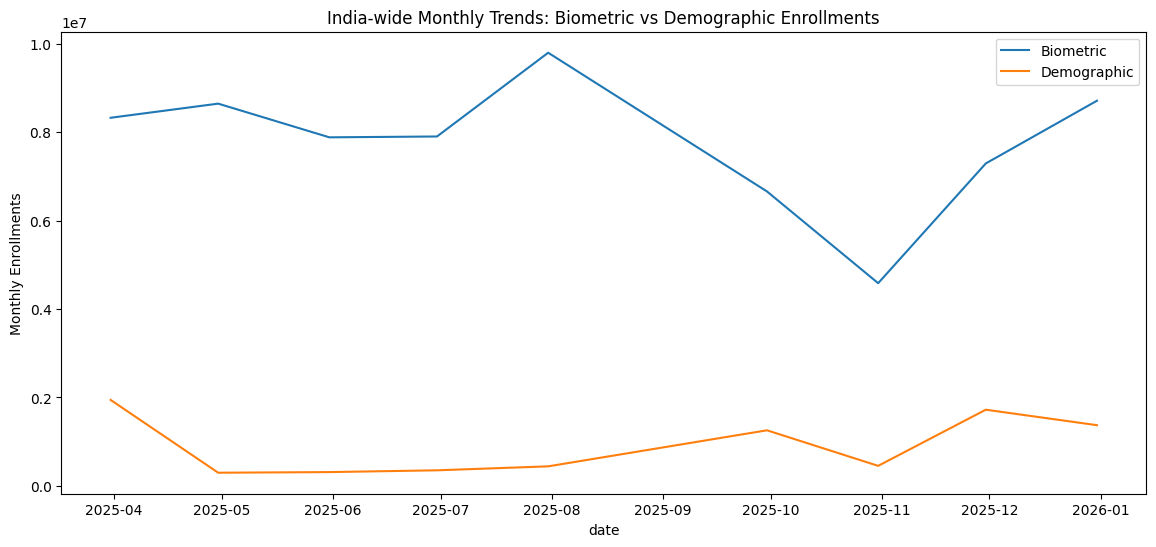

In [ ]:
national = df_state_date.groupby('date').sum().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=national, x='date', y='total_enrollment_biometric', label='Biometric')
sns.lineplot(data=national, x='date', y='total_enrollment_demographic', label='Demographic')
plt.title('India-wide Monthly Trends: Biometric vs Demographic Enrollments')
plt.ylabel('Monthly Enrollments')
plt.show()

# bivariate


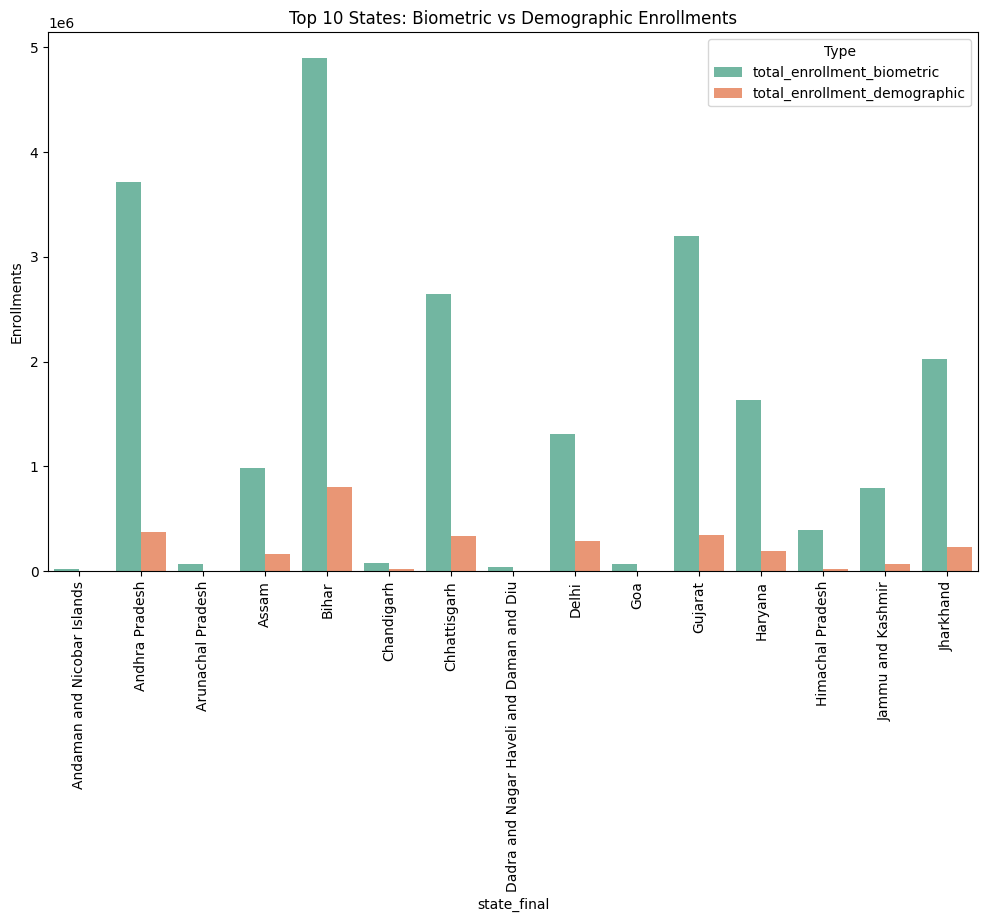

In [ ]:
top10 = df_state_summary.head(15)
top10_melt = top10.melt(id_vars='state_final',
                        value_vars=['total_enrollment_biometric', 'total_enrollment_demographic'],
                        var_name='Type', value_name='Enrollments')

plt.figure(figsize=(12, 7))
sns.barplot(data=top10_melt, x='state_final', y='Enrollments', hue='Type', palette='Set2')
plt.title('Top 10 States: Biometric vs Demographic Enrollments')
plt.xticks(rotation=90)
plt.show()

# Trivariate Visualizations

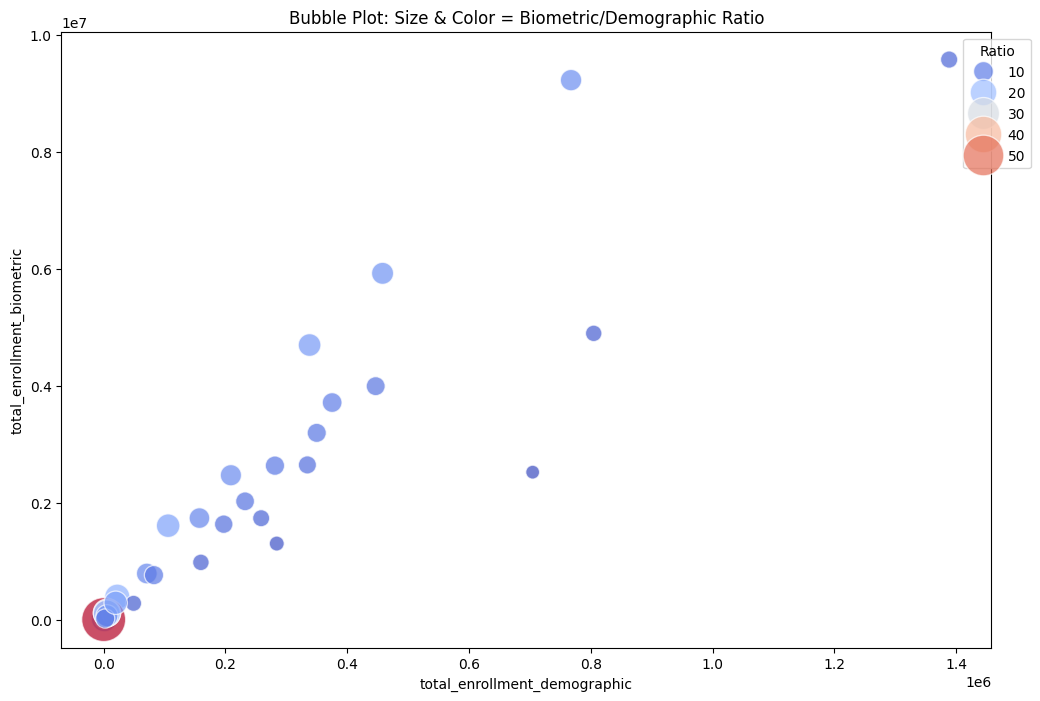

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_state_summary, x='total_enrollment_demographic',
                y='total_enrollment_biometric', size='bio_demo_ratio',
                hue='bio_demo_ratio', palette='coolwarm', sizes=(100, 1000), alpha=0.7)
plt.title('Bubble Plot: Size & Color = Biometric/Demographic Ratio')
plt.legend(title='Ratio', bbox_to_anchor=(1.05, 1))
plt.show()

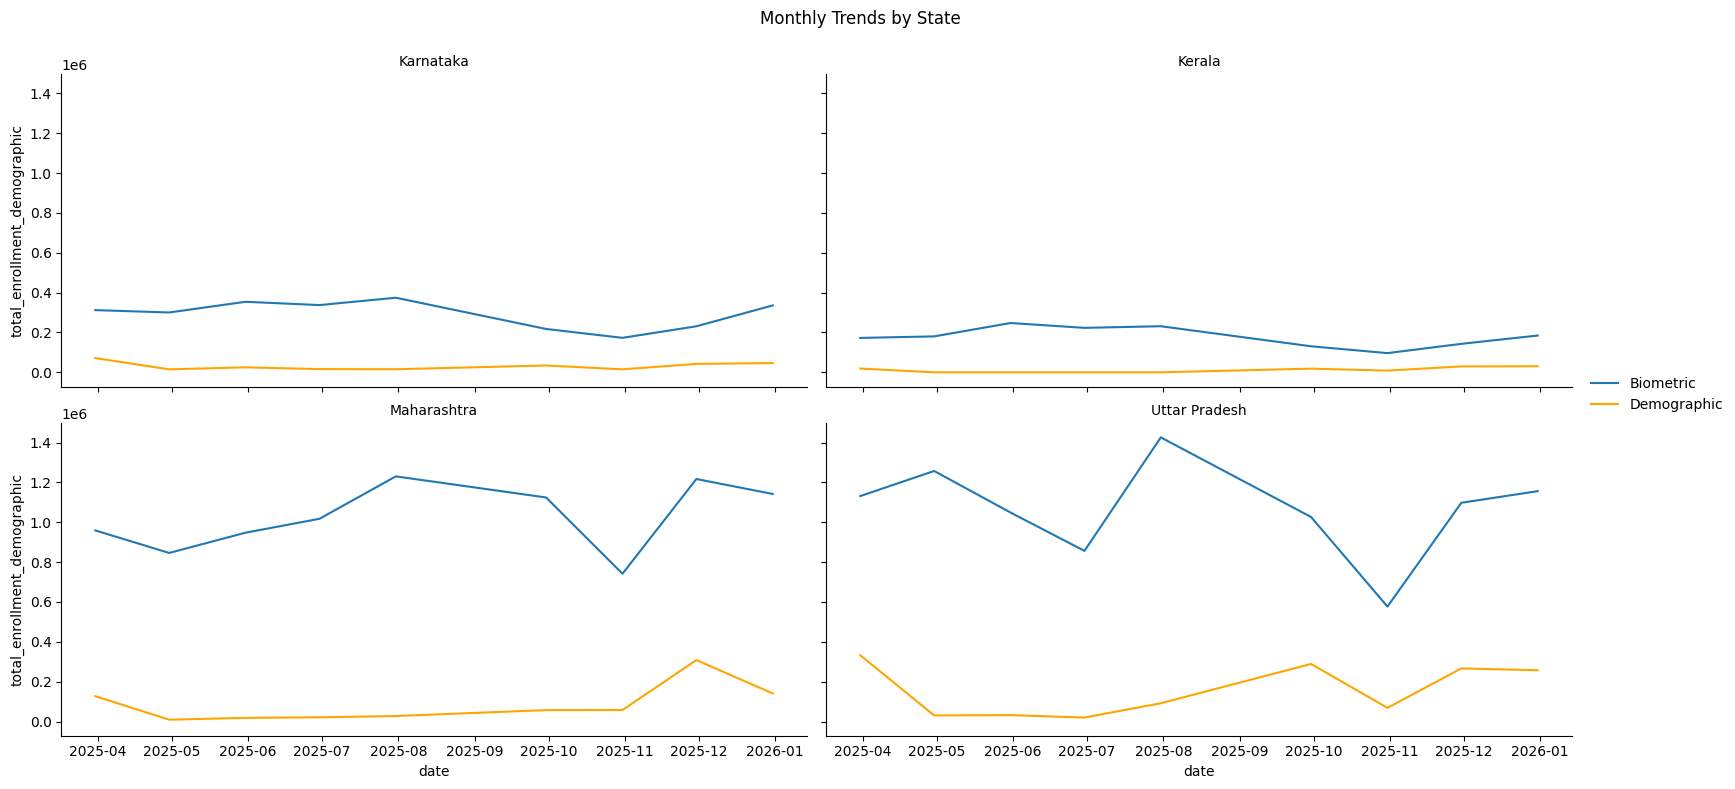

In [ ]:
top_states = ['Uttar Pradesh', 'Maharashtra', 'Kerala', 'Karnataka']
kerala_focus = df_state_date[df_state_date['state_final'].isin(top_states)]

g = sns.FacetGrid(kerala_focus, col='state_final', col_wrap=2, height=4, aspect=2)
g.map(sns.lineplot, 'date', 'total_enrollment_biometric', label='Biometric')
g.map(sns.lineplot, 'date', 'total_enrollment_demographic', color='orange', label='Demographic')
g.add_legend()
g.set_titles('{col_name}')
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Monthly Trends by State')
plt.show()

In [ ]:
import geopandas as gpd
import plotly.express as px

# Download India states geojson if needed: https://github.com/geohacker/india-states
india = gpd.read_file('india_states.geojson')
india = india.merge(df_state_summary, left_on='NAME_1', right_on='state_final', how='left')

fig = px.choropleth(india, geojson=india.geometry, locations=india.index,
                    color='total_enrollment_demographic',
                    color_continuous_scale='Blues',
                    title='Total Demographic Enrollments by State')
fig.show()